In [1]:
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text,plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

In [3]:
df = pd.read_csv ('titanik.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(columns = ['PassengerId','Name','Ticket','Cabin'], inplace = True)

In [5]:
df['Age'] = df['Age'].fillna(28)

In [6]:
df['Embarked'] = df['Embarked'].fillna('U')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [8]:
df['Sex'] = np.where(df['Sex'] == 'male', 1,0)

In [9]:
df['Embarked'] = df['Embarked'].map({'U':0, 'S':1,'C':2, 'Q':3})
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,1
1,1,1,0,38.0,1,0,71.2833,2
2,1,3,0,26.0,0,0,7.9250,1
3,1,1,0,35.0,1,0,53.1000,1
4,0,3,1,35.0,0,0,8.0500,1


In [10]:
array = df.values
X = array[:,1::]

In [11]:
X.shape

(891, 7)

In [12]:
y = array[:,0]

In [13]:
X_train,X_test,y_train,y_test = train_test_split (X,y, test_size = 0.2, random_state = 17)

In [14]:
models = []
models.append(('knn',KNeighborsClassifier()))
models.append(('logreg',LogisticRegression()))
models.append(('svc',SVC()))
models.append(('gb',GaussianNB()))
models.append(('cart',DecisionTreeClassifier()))
models.append(('ld', LinearDiscriminantAnalysis()))
models.append(('mlp', MLPClassifier(max_iter = 1000)))

In [15]:
for name, model in models:
    fitted = model.fit(X_train,y_train)
    y_pred = fitted.predict (X_test)
    f1 = f1_score (y_test,y_pred)
    print (f'{name}: {f1}')

knn: 0.5511811023622047
logreg: 0.6944444444444444
svc: 0.4423076923076923
gb: 0.7183098591549296
cart: 0.7482993197278912
ld: 0.6811594202898551
mlp: 0.75


In [16]:
model = DecisionTreeClassifier().fit(X_train, y_train).predict(X_test)

In [17]:
confusion_matrix (y_test, model)

array([[85, 21],
       [20, 53]])

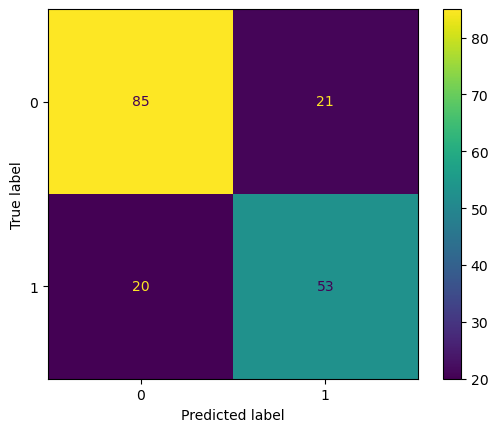

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix (y_test, model))
disp.plot();

In [19]:
print(classification_report(y_test,model))

              precision    recall  f1-score   support

         0.0       0.81      0.80      0.81       106
         1.0       0.72      0.73      0.72        73

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



In [20]:
roc_auc_score (y_test, model)

0.7639570948565519

In [21]:
auc = roc_auc_score (y_test, model)

In [22]:
roc_curve(y_test, model)

(array([0.        , 0.19811321, 1.        ]),
 array([0.       , 0.7260274, 1.       ]),
 array([inf,  1.,  0.]))

In [23]:
fpr,tpr, _ = roc_curve(y_test, model)

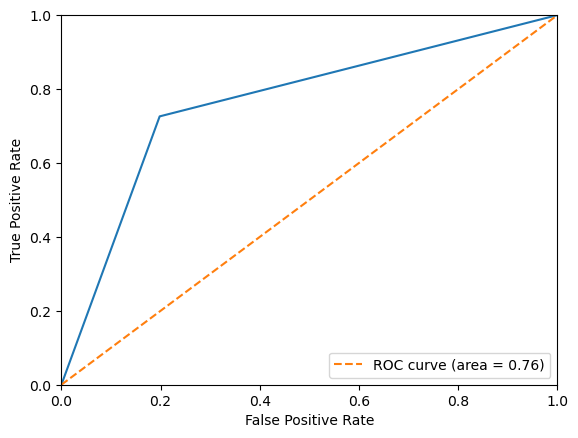

In [24]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1], linestyle = '--', label = 'ROC curve (area = %0.2f)' % auc)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.legend(loc = 'lower right');

# Балансировка данных

In [25]:
counter = Counter(df['Survived'])
print(counter)

Counter({0: 549, 1: 342})


### 1. Взвешивание классов

In [26]:
from sklearn.utils.class_weight import compute_class_weight

In [27]:
# Получение весов классов
class_weights = compute_class_weight ('balanced', classes = np.unique(df['Survived']), y = df['Survived'])

In [28]:
class_weights

array([0.81147541, 1.30263158])

In [29]:
model = DecisionTreeClassifier (class_weight = dict(enumerate(class_weights)))
model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 0.8114754098360656, 1: 1.3026315789473684}"


In [30]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 0.8114754098360656, 1: 1.3026315789473684}"


In [31]:
y_pred = model.predict(X_test)

In [32]:
f1_score(y_test,y_pred)

0.726027397260274

### 2. Увеличение выборки

In [33]:
from imblearn.over_sampling import RandomOverSampler

In [34]:
x = df.loc[:,'Pclass':'Embarked']
y = df['Survived']

In [35]:
ros = RandomOverSampler()

In [36]:
X_resampled, y_resampled = ros.fit_resample(x,y)

In [37]:
Counter(y_resampled)

Counter({0: 549, 1: 549})

In [38]:
x_train,x_test,y_train,y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state= 17)

In [41]:
model = DecisionTreeClassifier().fit(x_train,y_train)
y_pred = model.predict(x_test)
f1_score(y_test,y_pred)

0.8584070796460177

### 3. Уменьшение выборки

In [43]:
from imblearn.under_sampling import RandomUnderSampler

In [44]:
rus = RandomUnderSampler()

In [45]:
X_resampled, y_resampled = rus.fit_resample(x,y)
Counter(y_resampled)

Counter({0: 342, 1: 342})

In [46]:
x_train,x_test,y_train,y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state= 17)

In [47]:
model = DecisionTreeClassifier().fit(x_train,y_train)
y_pred = model.predict(x_test)
f1_score(y_test,y_pred)

0.726027397260274

### 4. SMOTE (Synthetic Minority Over-sampling Technique)

In [48]:
from imblearn.over_sampling import SMOTE

In [49]:
smote = SMOTE()

In [50]:
X_resampled, y_resampled =  smote.fit_resample(x,y)
Counter(y_resampled)

Counter({0: 549, 1: 549})

In [51]:
x_train,x_test,y_train,y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state= 17)

In [52]:
model = DecisionTreeClassifier().fit(x_train,y_train)
y_pred = model.predict(x_test)
f1_score(y_test,y_pred)

0.8372093023255814

### ADASYN (Adaptive Synthetic Sampling)

In [53]:
from imblearn.over_sampling import ADASYN

In [54]:
adasyn = ADASYN()

In [55]:
X_resampled, y_resampled =  adasyn.fit_resample(x,y)
Counter(y_resampled)

Counter({1: 576, 0: 549})

In [56]:
x_train,x_test,y_train,y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state= 17)

In [57]:
model = DecisionTreeClassifier().fit(x_train,y_train)
y_pred = model.predict(x_test)
f1_score(y_test,y_pred)

0.8067226890756303